Linear fit coefficients:
Slope: 2.384368e-02
Intercept: 0.024246


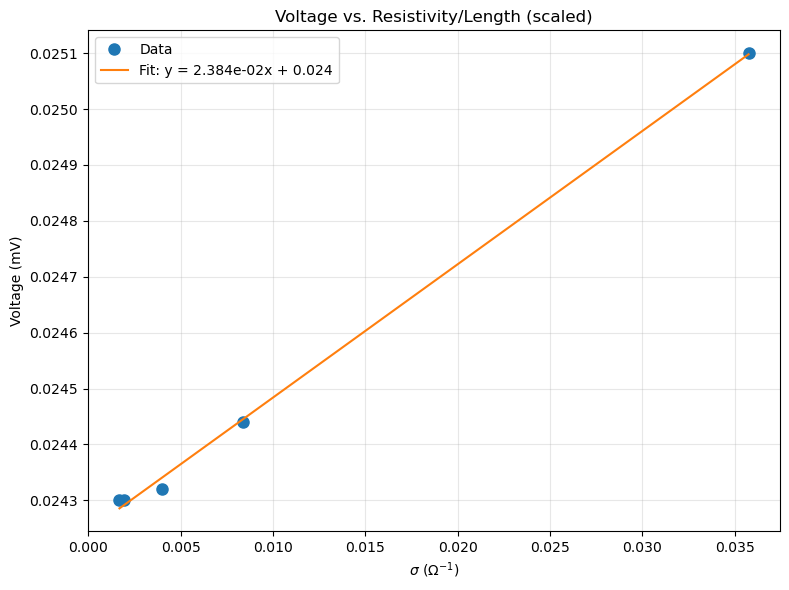

R²: 0.9985


In [40]:
# Task 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as p

# import csv - note: CSV has spaces after commas, need to handle
data = pd.read_csv('data1.csv', skipinitialspace=True)

# plot the data
# Convert units: res is in ohm*cm, l is in micrometers
# Calculate res/l in units of ohm
# res/l = (ohm*cm) / (micrometer) = (ohm*cm) / (10^-4 cm) = 10^4 ohm
data['res_over_l'] = data['res'] / data['l'] * 1e4
data['l_over_res'] = 1 / data['res_over_l']

# Scale voltages
v_scaled = data['v'] * 2e-2

# Perform linear fit
coeffs = np.polyfit(data['l_over_res'], v_scaled, 1)
slope = coeffs[0]
intercept = coeffs[1]

# Print coefficients
print(f"Linear fit coefficients:")
print(f"Slope: {slope:.6e}")
print(f"Intercept: {intercept:.6f}")

# Plot voltage vs res/l
p.figure(figsize=(8, 6))
p.plot(data['l_over_res'], v_scaled, 'o', markersize=8, label='Data')
# Plot fit line
x_fit = np.linspace(data['l_over_res'].min(), data['l_over_res'].max(), 100)
y_fit = slope * x_fit + intercept
p.plot(x_fit, y_fit, '-', label=f'Fit: y = {slope:.3e}x + {intercept:.3f}')
p.xlabel(r'$\sigma$ ($\Omega^{-1}$)')
p.ylabel('Voltage (mV)')
p.title('Voltage vs. Resistivity/Length (scaled)')
p.legend()
p.grid(True, alpha=0.3)
p.tight_layout()
p.show()

# Print R² and define conductance_from_voltage function using fit values from previous cell
y_pred = slope * data['l_over_res'] + intercept
ss_res = np.sum((v_scaled - y_pred) ** 2)
ss_tot = np.sum((v_scaled - np.mean(v_scaled)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
print(f"R²: {r2:.4f}")

def conductance_from_voltage(voltage, slope=slope, intercept=intercept):
    """Calculate conductance (l_over_res) from voltage using fit parameters."""
    return (voltage - intercept) / slope

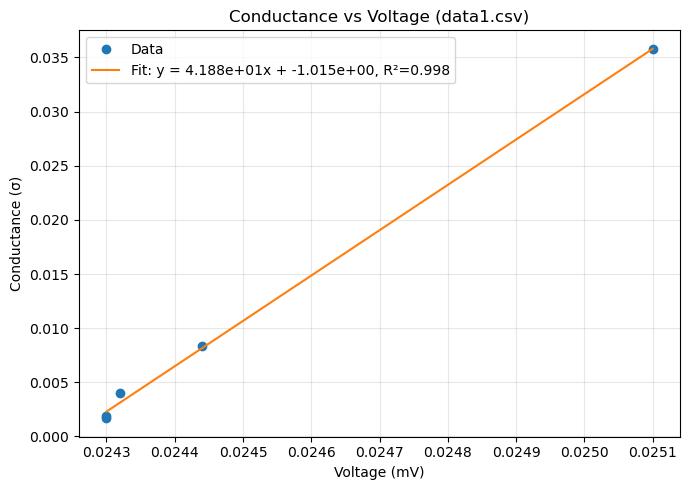

Fit slope: 4.187684e+01
Fit intercept: -1.015311e+00
R²: 0.9985


In [88]:
# Plot conductance (sigma) as a function of v from data1.csv, with linear fit and print fit params and R²
x = data['v']*2e-2
y = data['l_over_res']
fit_coeffs = np.polyfit(x, y, 1)
fit_slope, fit_intercept = fit_coeffs
fit_y = fit_slope * x + fit_intercept
ss_res = np.sum((y - fit_y) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(x, y, 'o', label='Data')
plt.plot(x, fit_y, '-', label=f'Fit: y = {fit_slope:.3e}x + {fit_intercept:.3e}, R²={r2:.3f}')
plt.xlabel('Voltage (mV)')
plt.ylabel('Conductance (σ)')
plt.title('Conductance vs Voltage (data1.csv)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Fit slope: {fit_slope:.6e}')
print(f'Fit intercept: {fit_intercept:.6e}')
print(f'R²: {r2:.4f}')

In [89]:
# Calculate conductance and d for task7.csv and save result
import pandas as pd

task7 = pd.read_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv')
task7['conductance'] = conductance_from_voltage(task7['v'] * 2e-2)  # scale voltage
task7['d'] = task7['conductance'] * task7['res']
task7.to_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv', index=False)
task7

,i,v,res,conductance,d
0,D030,1.232,21.000,0.016543,0.347408
1,V42,1.326,4.320,0.095390,0.412085
2,ing1,1.382,3.018,0.142363,0.429651
3,china,1.574,1.000,0.303412,0.303412
4,l1_p,1.639,0.685,0.357933,0.245184
5,S9,1.753,0.370,0.453556,0.167816
6,feri,1.882,0.147,0.561761,0.082579


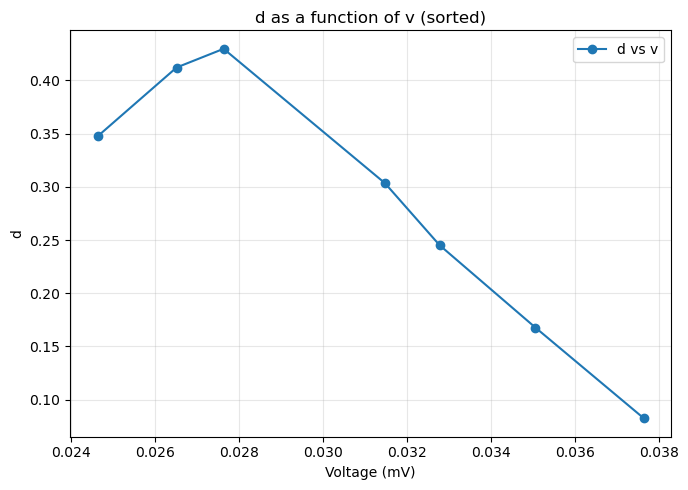

In [45]:
# Reload, sort by v, save, and plot d as a function of v
task7_sorted = pd.read_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv').sort_values('v')
task7_sorted.to_csv('gregorio-jaca-peter-tallosy_ePCD/task7.csv', index=False)
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(task7_sorted['v'] * 2e-2, task7_sorted['d'], 'o-', label='d vs v')  # scale voltage
plt.xlabel('Voltage (mV)')
plt.ylabel('d')
plt.title('d as a function of v (sorted)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# task7_sorted

it says to fit a suitable function but wtf
maybe we can say that it is linear, but below a certain point, then it is not properly measured
@petya

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob

def read_trn_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    # Find where the data starts (first line with two numbers)
    data_start = None
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) == 2:
            try:
                float(parts[0])
                float(parts[1])
                data_start = i
                break
            except ValueError:
                continue
    if data_start is None:
        raise ValueError(f"No data found in {filepath}")
    # Read data
    data = np.loadtxt(lines[data_start:])
    times = data[:, 0]
    values = data[:, 1]
    return times, values

def plot_trn_file(filepath, label=None):
    times, values = read_trn_file(filepath)
    plt.plot(times, values, label=label or os.path.basename(filepath))

def plot_trn_directory(directory):
    trn_files = glob(os.path.join(directory, '*.trn'))
    plt.figure(figsize=(10, 6))
    for f in trn_files:
        plot_trn_file(f)
    plt.xlabel('Time (us or ns)')
    plt.ylabel('Signal (mV)')
    plt.title('uPCD Transient Files')
    plt.legend()
    plt.show()

def analyze_trn_file(filepath):
    times, values = read_trn_file(filepath)
    stats = {
        'mean': np.mean(values),
        'std': np.std(values),
        'min': np.min(values),
        'max': np.max(values),
        'median': np.median(values),
        'rms': np.sqrt(np.mean(values**2)),
        'n_points': len(values)
    }
    return stats

# Example usage:
# plot_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
# plot_trn_directory('gregorio-jaca-peter-tallosy_ePCD/first')
# stats = analyze_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
# print(stats)


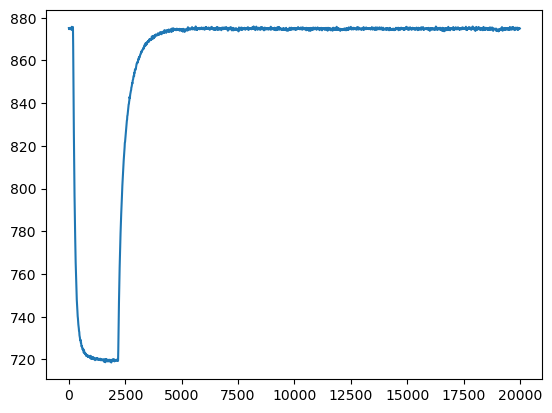

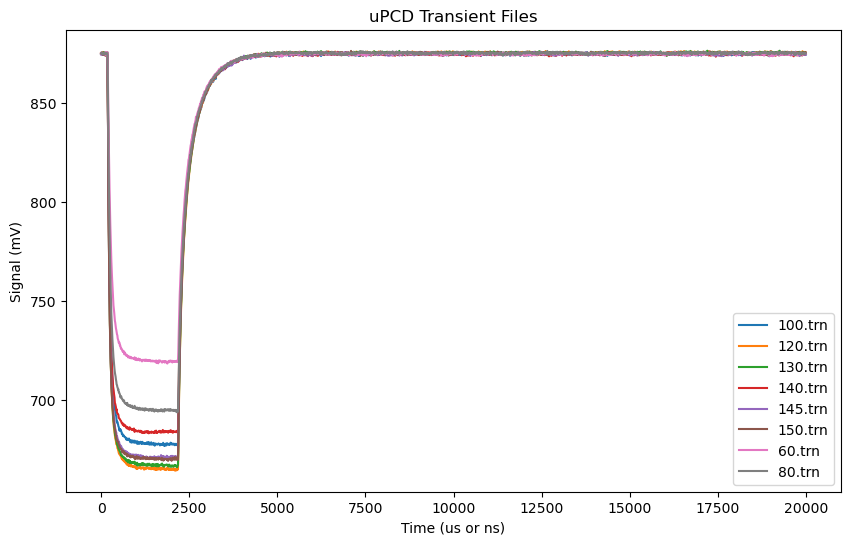

{'mean': 875.0419249999999, 'std': 1.0023048659839129, 'min': 871.55, 'max': 879.15, 'median': 874.98, 'rms': 875.0424990380468, 'n_points': 2000}


In [66]:
plot_trn_file('gregorio-jaca-peter-tallosy_ePCD/first/60.trn')
plot_trn_directory('gregorio-jaca-peter-tallosy_ePCD/first')
stats = analyze_trn_file('gregorio-jaca-peter-tallosy_ePCD/dc-level.trn')
print(stats)

In [67]:
import re
from scipy.optimize import curve_fit, minimize_scalar
from scipy.stats import linregress

def parse_trn_header(filepath):
    """Parse header for units and metadata."""
    header = {}
    with open(filepath, 'r') as f:
        for line in f:
            if re.match(r'^\d+\s', line):
                break
            if ':' in line:
                key, val = line.split(':', 1)
                header[key.strip()] = val.strip()
    # Extract units
    time_unit = 'us'
    voltage_unit = 'mV'
    for k, v in header.items():
        if 'Timebase' in k and 'us' in v:
            time_unit = 'us'
        if 'Delta' in k and 'ns' in v:
            time_unit = 'ns'
        if 'Amplitude' in k and 'mV' in v:
            voltage_unit = 'mV'
    return header, time_unit, voltage_unit



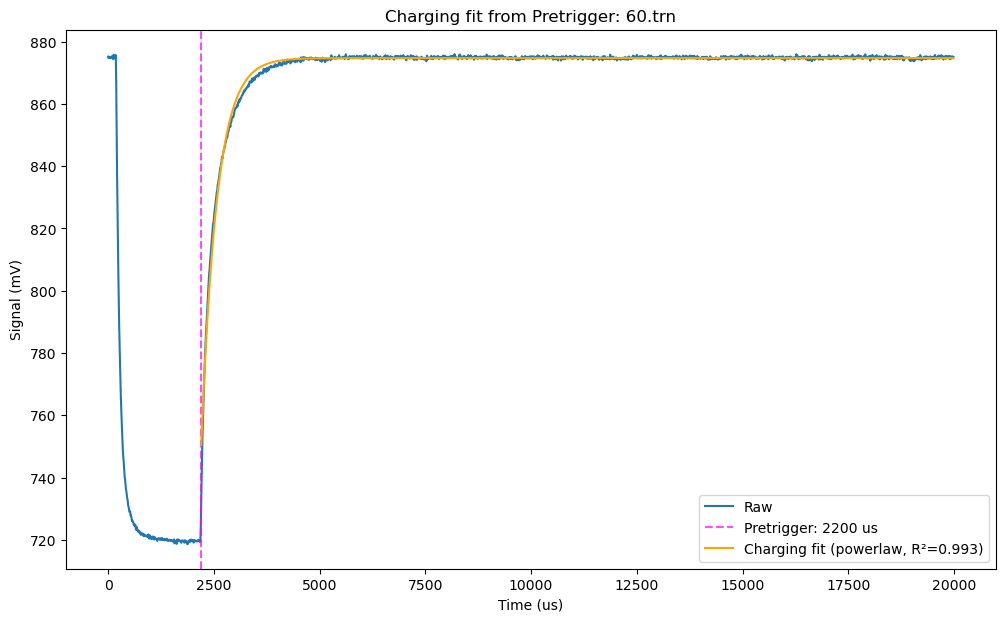

Fit parameters: A=124.274, tau=370.310, t0=3162.048, n=0.000, O=750.415
R²: 0.9926


In [75]:
# Fit charging region from Pretrigger to end, plot and show R²
import re
from scipy.optimize import curve_fit

def charging_func_exp(t, A, tau, C):
    """Simple exponential charging: A * (1 - exp(-t/tau)) + C"""
    return A * (1 - np.exp(-t / tau)) + C

def charging_func_powerlaw(t, A, tau, t0, n, O):
    """Power-law charging: A * exp(-t/tau) / (1 + t/t0)**n + O"""
    return A * (1-np.exp(-t / tau)) / ((1 + (t / t0))**n) + O

def fit_charging_from_pretrigger(filepath, model='powerlaw'):
    times, values = read_trn_file(filepath)
    header, time_unit, voltage_unit = parse_trn_header(filepath)
    # Find Pretrigger value
    if 'Pretrigger' not in header:
        raise ValueError('Pretrigger not found in header')
    pre_val = header['Pretrigger']
    pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
    # Convert units if needed
    if 'us' in pre_val:
        pre_time = pre_num
    elif 'ns' in pre_val:
        pre_time = pre_num / 1000.0
    else:
        pre_time = pre_num
    # Find index where time >= pretrigger
    start_idx = np.argmax(times >= pre_time)
    x = times[start_idx:] - times[start_idx]  # shift to t=0 at pretrigger
    y = values[start_idx:]

    if model == 'exp':
        # Estimate initial parameters for exponential fit
        A0 = y[-1] - y[0]  # amplitude (final - initial)
        tau0 = (x[-1] - x[0]) / 3 if (x[-1] - x[0]) > 0 else 1.0  # rough guess
        C0 = y[0]  # baseline
        p0 = [A0, tau0, C0]
        bounds = ([0, 0, min(y)], [max(y)-min(y), np.inf, max(y)])
        fit_func = charging_func_exp
        fit_label = 'exp'
        fit_params = ['A', 'tau', 'C']
    elif model == 'powerlaw':
        # Improved initial guess for powerlaw
        A0 = max(y) - min(y)
        # Estimate tau0 using log(y) decay if possible
        try:
            y_log = np.log(np.maximum(y - min(y), 1e-9))
            tau0 = - (x[-1] - x[0]) / (y_log[-1] - y_log[0]) if (y_log[-1] - y_log[0]) != 0 else 1.0
            if tau0 <= 0 or np.isnan(tau0): tau0 = (x[-1] - x[0]) / 2
        except Exception:
            tau0 = (x[-1] - x[0]) / 2
        t0_0 = tau0
        n0 = 10.0
        O0 = min(y)
        # Try multiple initial guesses for robustness
        p0_list = [
            [A0, tau0, t0_0, n0, O0],
            [A0, tau0*0.5, t0_0*2, 0.5, O0],
            [A0, tau0*2, t0_0*0.5, 2.0, O0],
        ]
        bounds = ([0, 0, 0, 0, min(y)], [np.inf, np.inf, np.inf, 10, max(y)])
        fit_func = charging_func_powerlaw
        fit_label = 'powerlaw'
        fit_params = ['A', 'tau', 't0', 'n', 'O']
    else:
        raise ValueError('Unknown model type. Use "exp" or "powerlaw".')

    popt, r2 = None, None
    for p0 in p0_list if model == 'powerlaw' else [p0]:
        try:
            popt_try, _ = curve_fit(fit_func, x, y, p0=p0, bounds=bounds, maxfev=10000)
            yfit_try = fit_func(x, *popt_try)
            ss_res = np.sum((y - yfit_try) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2_try = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf
            if popt is None or (r2_try is not None and (r2 is None or r2_try > r2)):
                popt, r2, yfit = popt_try, r2_try, yfit_try
        except Exception as e:
            continue

    # Plot
    plt.figure(figsize=(12, 7))
    plt.plot(times, values, label='Raw')
    plt.axvline(times[start_idx], color='magenta', linestyle='--', alpha=0.7, label=f'Pretrigger: {pre_val}')
    if popt is not None:
        plt.plot(times[start_idx:], yfit, '-', color='orange', label=f'Charging fit ({fit_label}, R²={r2:.3f})')
    plt.xlabel(f'Time ({time_unit})')
    plt.ylabel(f'Signal ({voltage_unit})')
    plt.title(f'Charging fit from Pretrigger: {os.path.basename(filepath)}')
    plt.legend()
    plt.show()
    if popt is not None:
        print('Fit parameters: ' + ', '.join([f'{k}={v:.3f}' for k, v in zip(fit_params, popt)]))
        print(f'R²: {r2:.4f}')
    else:
        print('No fit')

# Example usage:
fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='powerlaw')
# fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='exp')


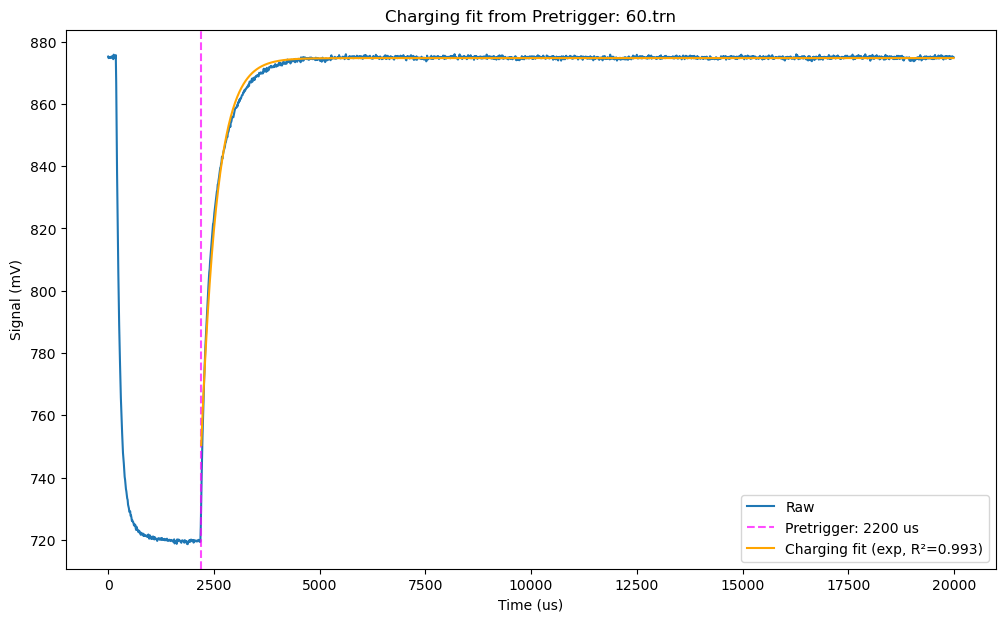

Fit parameters: A=124.274, tau=370.310, C=750.415
R²: 0.9926


In [74]:
fit_charging_from_pretrigger('gregorio-jaca-peter-tallosy_ePCD/first/60.trn', model='exp')

In [70]:
# Batch process all .trn files, fit charging, extract header, and save results to CSV
import os
import pandas as pd
from glob import glob

def batch_fit_charging_and_save_csv(root_dir, csv_path='charging_fit_results.csv', model='exp'):
    results = []
    # Recursively find all .trn files, including subdirectories
    all_trn = []
    for dirpath, _, _ in os.walk(root_dir):
        files = glob(os.path.join(dirpath, '*.trn'))
        all_trn.extend(files)
    # Sort by directory then filename
    all_trn = sorted(all_trn, key=lambda x: (os.path.relpath(os.path.dirname(x), root_dir), os.path.basename(x)))
    for f in all_trn:
        try:
            times, values = read_trn_file(f)
            header, time_unit, voltage_unit = parse_trn_header(f)
            # Fit charging region
            pre_val = header.get('Pretrigger', None)
            if pre_val is None:
                continue
            pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
            if 'us' in pre_val:
                pre_time = pre_num
            elif 'ns' in pre_val:
                pre_time = pre_num / 1000.0
            else:
                pre_time = pre_num
            start_idx = np.argmax(times >= pre_time)
            x = times[start_idx:] - times[start_idx]
            y = values[start_idx:]

            if model == 'exp':
                C0 = min(y)
                A0 = max(y) - min(y)
                tau0 = (x[-1] - x[0]) / 3 if (x[-1] - x[0]) > 0 else 1.0
                p0 = [A0, tau0, C0]
                bounds = ([0, 0, min(y)], [np.inf, np.inf, max(y)])
                fit_func = charging_func_exp
            elif model == 'powerlaw':
                A0 = max(y) - min(y)
                tau0 = (x[-1] - x[0]) / 2 if (x[-1] - x[0]) > 0 else 1.0
                t0_0 = tau0
                n0 = 1.0
                O0 = min(y)
                p0 = [A0, tau0, t0_0, n0, O0]
                bounds = ([0, 0, 0, 0, min(y)], [np.inf, np.inf, np.inf, 5, max(y)])
                fit_func = charging_func_powerlaw
            else:
                continue

            popt, _ = curve_fit(fit_func, x, y, p0=p0, bounds=bounds, maxfev=5000)
            yfit = fit_func(x, *popt)
            ss_res = np.sum((y - yfit) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf
            # Collect header and fit results
            row = {
                'file': os.path.relpath(f, root_dir),
                'r2': r2
            }
            if model == 'exp':
                row.update({'tau': popt[1], 'A': popt[0], 'C': popt[2]})
            else:
                row.update({'tau': popt[1], 'A': popt[0], 't0': popt[2], 'n': popt[3], 'O': popt[4]})
            for k, v in header.items():
                row[k] = v
            results.append(row)
        except Exception as e:
            print(f'Error processing {f}: {e}')
    df = pd.DataFrame(results)
    if model == 'exp':
        fit_cols = ['file', 'tau', 'A', 'C', 'r2']
    else:
        fit_cols = ['file', 'tau', 'A', 't0', 'n', 'O', 'r2']
    header_cols = [c for c in df.columns if c not in fit_cols]
    df = df[fit_cols + header_cols]
    df.to_csv(csv_path, index=False)
    print(f'Saved results to {csv_path}')

# Example usage:
batch_fit_charging_and_save_csv("gregorio-jaca-peter-tallosy_ePCD", model='exp')
# batch_fit_charging_and_save_csv("gregorio-jaca-peter-tallosy_ePCD", model='powerlaw')


KeyboardInterrupt: 

In [58]:
# Post-process charging_fit_results.csv: plot tau and Lifetime vs intensity for each relevant subdirectory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv('charging_fit_results.csv')

# Only keep rows where 'file' matches pattern: subdir(s)/intensity.trn
pattern = re.compile(r'(.+[\\/])?(\d+)\.trn$')
relevant = df['file'].apply(lambda x: bool(pattern.match(x)))
df_relevant = df[relevant].copy()

# Extract subdirectory and intensity
def extract_subdir_intensity(f):
    m = pattern.match(f)
    if m:
        subdir = m.group(1) or ''
        intensity = int(m.group(2))
        return subdir.rstrip('\\/'), intensity
    return None, None

df_relevant[['subdir', 'intensity']] = df_relevant['file'].apply(lambda f: pd.Series(extract_subdir_intensity(f)))


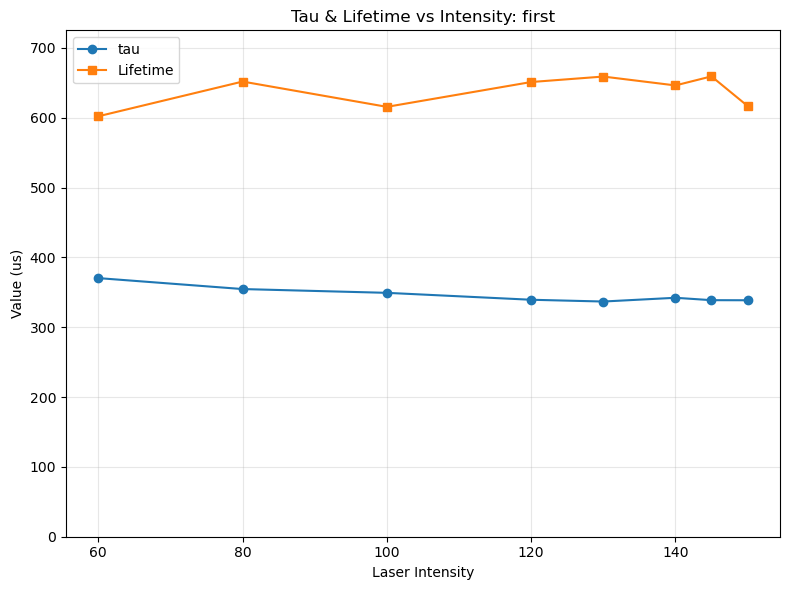

7    602.06
8    651.77
1    615.55
2    651.10
3    658.94
4    646.23
5    659.20
6    616.85
Name: Lifetime_float, dtype: float64
7    370.310744
8    354.641900
1    349.225971
2    339.326142
3    336.784492
4    342.153171
5    338.731163
6    338.596651
Name: tau, dtype: float64


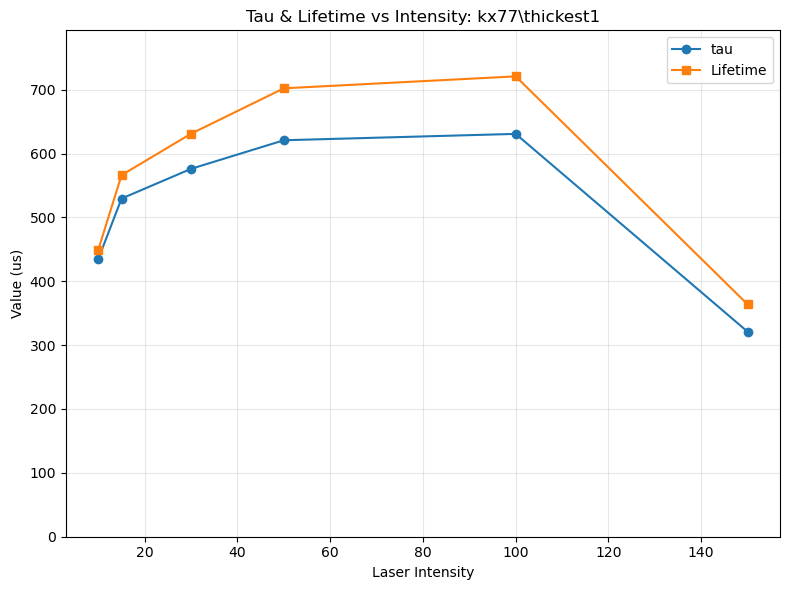

13    449.62
15    566.13
17    631.08
18    702.10
14    720.79
16    363.93
Name: Lifetime_float, dtype: float64
13    435.045603
15    529.467658
17    576.054795
18    620.759341
14    630.741059
16    321.101951
Name: tau, dtype: float64


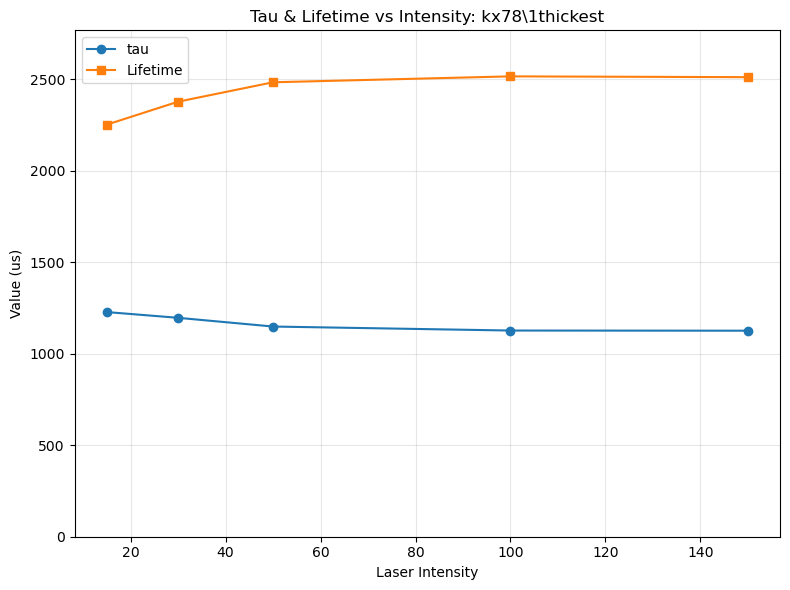

23    2252.7
25    2378.1
26    2484.2
22    2516.5
24    2512.1
Name: Lifetime_float, dtype: float64
23    1228.042014
25    1196.636148
26    1148.967241
22    1127.087931
24    1126.221777
Name: tau, dtype: float64


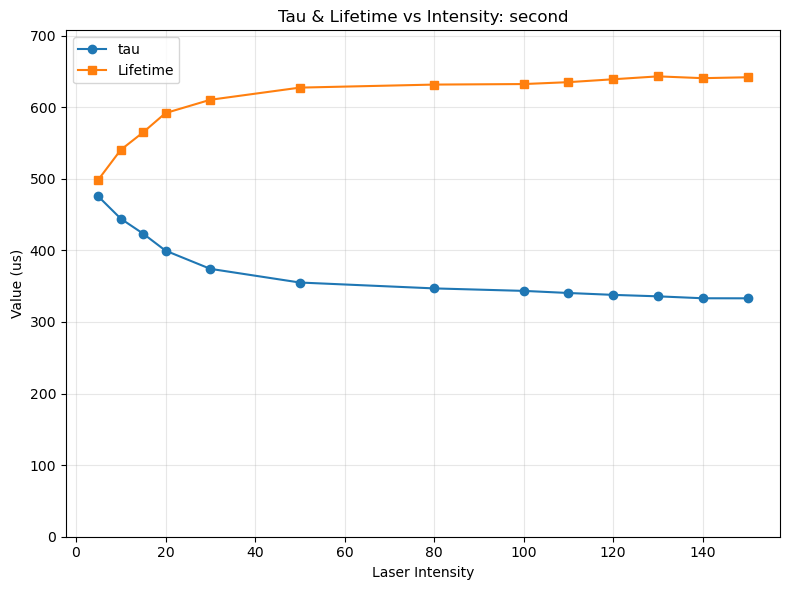

37    498.76
27    540.32
33    564.81
35    591.72
36    610.28
38    627.27
39    631.51
28    632.25
29    634.89
30    638.93
31    642.98
32    640.46
34    641.73
Name: Lifetime_float, dtype: float64
37    475.211234
27    444.250982
33    423.287816
35    399.565484
36    374.147293
38    355.036066
39    346.839900
28    343.364404
29    340.420539
30    337.793016
31    335.747051
32    333.055812
34    332.983631
Name: tau, dtype: float64


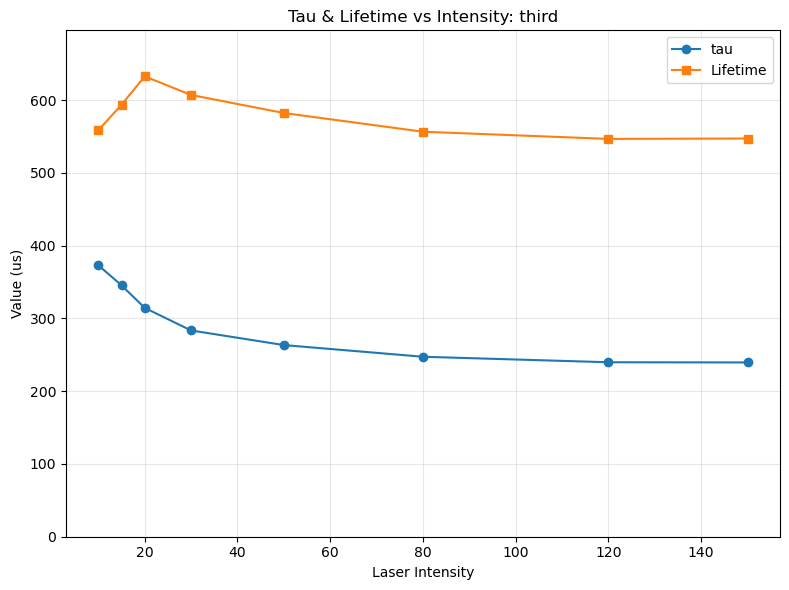

40    558.69
42    593.66
44    632.65
45    607.07
46    582.29
47    556.59
41    546.71
43    547.25
Name: Lifetime_float, dtype: float64
40    373.042127
42    345.469537
44    314.463797
45    283.453168
46    263.374578
47    247.326295
41    239.768530
43    239.501920
Name: tau, dtype: float64


In [60]:
# Joint plot: tau and Lifetime vs intensity for each subdirectory, Lifetime parsed to float
for subdir, group in df_relevant.groupby('subdir'):
    group_sorted = group.sort_values('intensity').copy()

    # Individual Lifetime plot (parse float from Lifetime column)
    if 'Lifetime' in group_sorted.columns:
        # # Extract float from Lifetime string (e.g., '757.97 us')
        group_sorted['Lifetime_float'] = group_sorted['Lifetime'].astype(str).str.extract(r'([\d\.]+)').astype(float)

        # Joint plot
        plt.figure(figsize=(8,6))
        plt.plot(group_sorted['intensity'], group_sorted['tau'], 'o-', label='tau')
        plt.plot(group_sorted['intensity'], group_sorted['Lifetime_float'], 's-', label='Lifetime')
        plt.xlabel('Laser Intensity')
        plt.ylabel('Value (us)')
        plt.title(f'Tau & Lifetime vs Intensity: {subdir}')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.1*max(max(group_sorted['tau']), max(group_sorted['Lifetime_float'])))
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(group_sorted['Lifetime_float'])
        print(group_sorted['tau'])
    else:
        print(f'No Lifetime column found for {subdir}')

so the semilab WT-1200I gives you a value for Lifetime, but I also fitted manually (getting very good fit quality r2 ~ 0.99) and the two values are quite different

In [61]:
# Iterative Calculation of Excess Carrier Concentration (Δn)
# Define all required parameters here (fill in missing values as needed)

# --- Constants and Inputs ---
e = 1.602e-19  # Electron charge [C]
W = ...        # Wafer thickness [cm]  # <-- Fill in from Task 9
N_dop = ...    # Doping concentration [cm^-3]  # <-- Fill in from datasheet
sigma_s = ...  # Measured sheet conductance [S/square]  # <-- Fill in from measurement (Task 6 or 9)
# For transient case, sigma_s should be an array: sigma_s_t = ...

# --- Initial Mobility Values (300 K, Δn=0) ---
mu_e_init = 1350  # Electron mobility [cm^2/Vs]
mu_h_init = 450   # Hole mobility [cm^2/Vs]

# --- Mobility Model ---
def get_mobilities(n_total, p_total):
    """
    Return (mu_e, mu_h) for given carrier concentrations.
    Replace this with Klaassen's model or use online calculator as needed.
    """
    # TODO: Implement/lookup mobility model here
    mu_e = mu_e_init  # Placeholder, update with model
    mu_h = mu_h_init  # Placeholder, update with model
    return mu_e, mu_h

# --- Iterative Solver for Δn ---
def solve_delta_n(sigma_s, W, N_dop, e, mu_e_init, mu_h_init, tol=1e10, max_iter=100):
    """
    Iteratively solve for Δn given measured sheet conductance sigma_s.
    Returns Δn [cm^-3].
    """
    # Initial guess
    delta_n_guess = 1e13
    for i in range(max_iter):
        # Carrier concentrations
        n_total = delta_n_guess  # For P-type, n_0 ≈ 0
        p_total = N_dop + delta_n_guess  # For P-type, p_0 ≈ N_dop
        # Mobilities
        mu_e, mu_h = get_mobilities(n_total, p_total)
        mu_sum = mu_e + mu_h
        mu_maj = mu_h  # For P-type
        # Calculate new Δn
        delta_n_new = (sigma_s/W - N_dop * mu_maj) / (e * mu_sum)
        # Convergence check
        if abs(delta_n_new - delta_n_guess) <= tol:
            return delta_n_new
        delta_n_guess = delta_n_new
    print('Warning: Δn did not converge')
    return delta_n_new

# --- Steady-State Case ---
# Example usage (fill in actual values above):
# delta_n_ss = solve_delta_n(sigma_s, W, N_dop, e, mu_e_init, mu_h_init)
# print(f'Steady-state Δn: {delta_n_ss:.3e} cm^-3')

# --- Transient Case ---
# If sigma_s_t is an array of sheet conductance values at each time t:
# delta_n_t = [solve_delta_n(s, W, N_dop, e, mu_e_init, mu_h_init) for s in sigma_s_t]
#
# # To calculate transient lifetime:
# # t_array = ... # time points corresponding to sigma_s_t
# # Use np.gradient for numerical derivative
# # dndt = np.gradient(delta_n_t, t_array)
# # tau_t = np.array(delta_n_t) / np.abs(dndt)
# #
# # Example plot:
# # import matplotlib.pyplot as plt
# # plt.plot(delta_n_t, tau_t)
# # plt.xlabel('Δn (cm^-3)')
# # plt.ylabel('τ (s)')
# # plt.title('Transient Lifetime vs Δn')
# # plt.show()

# --- Comments ---
# - Fill in missing parameters above.
# - Replace get_mobilities() with actual mobility model or calculator.
# - For transient case, supply sigma_s_t and t_array.
# - For steady-state, use measured max sigma_s.


In [ ]:
# ⚙️ Iterative Δn Calculation Algorithm for N-type Si
# Implements Caughey-Thomas mobility model (Klaassen params) for μ_e, μ_h
# Fill in missing values for your sample at the top

import numpy as np

# --- 1. Initialization and Setup ---
e = 1.602e-19  # Electron charge [C]
W = ...        # Wafer thickness [cm]  # <-- Fill in
N_D = ...      # Donor concentration [cm^-3]  # <-- Fill in (N-type, e.g. 3.69e15)
N_A = 0        # Acceptor concentration [cm^-3] (assume 0 for N-type)
sigma_s = ...  # Measured sheet conductance [S/cm]  # <-- Fill in
TOL = 1e10     # Convergence tolerance [cm^-3]
delta_n_guess = 1e13  # Initial guess [cm^-3]

# Intrinsic carrier concentration (for Si at 300K)
n_i = 1.0e10   # [cm^-3] (adjust if needed)
n_0 = N_D      # For N-type, n_0 ≈ N_D
p_0 = n_i**2 / N_D  # For N-type, p_0 ≈ n_i^2 / N_D

# --- 2. Caughey-Thomas Mobility Model Parameters (300K, Klaassen) ---
# Electron (μ_e)
mu_min_e = 52.2
mu_max_e = 1417
Nref1_e = 9.20e16
alpha1_e = 0.68
# Hole (μ_h)
mu_min_h = 44.9
mu_max_h = 470.5
Nref1_h = 2.23e17
alpha1_h = 0.70



# --- 3. Iterative Δn Solver ---
def solve_delta_n(sigma_s, W, N_D, N_A, e, tol=TOL, max_iter=100):
    """
    Iteratively solve for Δn given measured sheet conductance sigma_s [S/cm].
    Returns Δn [cm^-3].
    """
    n_0 = N_D
    n_i = 1.0e10
    p_0 = n_i**2 / N_D
    delta_n_guess = 1e13
    for i in range(max_iter):
        n_total = n_0 + delta_n_guess
        p_total = p_0 + delta_n_guess
        mu_e, mu_h = get_mobilities(N_D, N_A, n_total, p_total)
        mu_sum = mu_e + mu_h
        mu_maj = mu_e  # For N-type
        delta_n_new = (sigma_s/W - N_D * mu_maj) / (e * mu_sum)
        if abs(delta_n_new - delta_n_guess) <= tol:
            return delta_n_new
        delta_n_guess = delta_n_new
    print('Warning: Δn did not converge')
    return delta_n_new

# --- Example Usage ---
# delta_n = solve_delta_n(sigma_s, W, N_D, N_A, e)
# print(f'Δn: {delta_n:.3e} cm^-3')

# For transient case: sigma_s_t = ... (array of S/cm values)
# delta_n_t = [solve_delta_n(s, W, N_D, N_A, e) for s in sigma_s_t]


In [85]:
import math

def calculate_mobility_and_properties(
    material='c-Si', 
    dopant_species='P', 
    Ndop=1.0e16, 
    Delta_n=1.0e15, 
    Delta_p=1.0e15, 
    T=300.0,
    tau_eff_e=10e-6, 
    tau_eff_h=10e-6
):
    """
    Calculates carrier mobilities, diffusivities, and diffusion lengths for Silicon
    using the Klaassen Unified Mobility Model logic (PV Lighthouse).
    
    Inputs:
        material      : 'c-Si' (Only Silicon implemented)
        dopant_species: 'P' (Phosphorus, n-type) or 'B' (Boron, p-type)
        Ndop          : Substitutional dopant concentration [cm^-3]
        Delta_n       : Excess electron concentration [cm^-3]
        Delta_p       : Excess hole concentration [cm^-3]
        T             : Temperature [K]
        tau_eff_e     : Effective electron lifetime [s]
        tau_eff_h     : Effective hole lifetime [s]
        
    Returns:
        Dictionary containing n0, p0, n, p, mu_e, mu_h, mu_a, 
        De, Dh, Da, Le, Lh, La, rho0, rho
    """
    
    # --- Constants ---
    q = 1.60217663e-19
    k_B = 1.380649e-23
    kB_T = k_B * T
    VT = kB_T / q  # Thermal voltage

    # --- Intrinsic Carrier Concentration (ni) ---
    # Standard approximation for Si near 300K
    ni = 9.65e9 * (T / 300.0)**1.5

    # --- 1. Equilibrium Carrier Concentrations ---
    # Assuming complete ionisation (N_ionised = Ndop)
    N_ionised = Ndop
    
    if dopant_species == 'P':  # n-type
        n0 = N_ionised
        p0 = ni**2 / N_ionised
        # Scattering Centers for Equilibrium
        N_D = N_ionised
        N_A = 0.0
    elif dopant_species == 'B':  # p-type
        p0 = N_ionised
        n0 = ni**2 / N_ionised
        # Scattering Centers for Equilibrium
        N_D = 0.0
        N_A = N_ionised
    else:
        raise ValueError("Dopant species must be 'P' or 'B'")

    # --- 2. Steady-state Carrier Concentrations ---
    n = n0 + Delta_n
    p = p0 + Delta_p

    # --- 3. Mobility Calculation (Klaassen Model) ---
    
    # Klaassen Parameters for Silicon (from literature/PV Lighthouse defaults)
    # Electrons
    mu_max_e = 1414.0
    mu_min_e = 68.5
    theta_e = 2.285
    alpha_e = 0.711
    Nref_e = 9.20e16
    
    # Holes
    mu_max_h = 470.5
    mu_min_h = 44.9
    theta_h = 2.247
    alpha_h = 0.719
    Nref_h = 2.23e17

    # Lattice Scattering (Temperature Dependent)
    mu_L_e = mu_max_e * (T / 300.0)**(-theta_e)
    mu_L_h = mu_max_h * (T / 300.0)**(-theta_h)

    # Effective Scattering Densities (N_sc)
    # CRITICAL FIX: Majority carriers do NOT scatter off themselves.
    # N_sc_e (for electrons) = Donors + Acceptors + Holes
    # N_sc_h (for holes)     = Donors + Acceptors + Electrons
    
    # Steady-State N_sc
    N_sc_e = N_D + N_A + p
    N_sc_h = N_D + N_A + n
    
    # Equilibrium N_sc (for rho0)
    N_sc_e0 = N_D + N_A + p0
    N_sc_h0 = N_D + N_A + n0

    # -- Helper Function for Klaassen/Masetti Interpolation --
    def calculate_mu_imp(mu_min, mu_max, mu_L, N_sc, Nref, alpha):
        # Impurity scattering component combined with lattice
        # Standard Caughey-Thomas like form used in Klaassen
        term = (N_sc / Nref)**alpha
        mu_impurity_part = mu_min + (mu_max - mu_min) / (1 + term)
        
        # Matthiessen's rule combination (Simplified for implementation stability)
        # 1/mu = 1/mu_L + 1/mu_impurity_part - correction
        # For this script, we use the direct analytical function often used:
        # mu = mu_min + (mu_L - mu_min) / (1 + (N_sc/Nref)^alpha) 
        # Note: We use mu_L in place of mu_max to account for T-dependence of the lattice limit.
        
        return mu_min + (mu_L - mu_min) / (1 + term)

    # Calculate Steady-State Mobilities
    mu_e = calculate_mu_imp(mu_min_e, mu_max_e, mu_L_e, N_sc_e, Nref_e, alpha_e)
    mu_h = calculate_mu_imp(mu_min_h, mu_max_h, mu_L_h, N_sc_h, Nref_h, alpha_h)
    
    # Calculate Equilibrium Mobilities (for rho0)
    mu_e0 = calculate_mu_imp(mu_min_e, mu_max_e, mu_L_e, N_sc_e0, Nref_e, alpha_e)
    mu_h0 = calculate_mu_imp(mu_min_h, mu_max_h, mu_L_h, N_sc_h0, Nref_h, alpha_h)

    # --- 4. Ambipolar Mobility ---
    # Formula: mu_a = (n + p) * mu_e * mu_h / (n * mu_e + p * mu_h)
    mu_a = (n + p) * mu_e * mu_h / (n * mu_e + p * mu_h)

    # --- 5. Diffusivities ---
    # D = mu * k * T / q
    De = mu_e * VT
    Dh = mu_h * VT
    Da = mu_a * VT

    # --- 6. Diffusion Lengths ---
    # L = sqrt(D * tau)
    Le = math.sqrt(De * tau_eff_e)
    Lh = math.sqrt(Dh * tau_eff_h)
    
    # Ambipolar Diffusion Length (La)
    # Using the minority lifetime for the ambipolar length is standard
    if dopant_species == 'P': # n-type, holes are minority
        tau_a = tau_eff_h
    else:                     # p-type, electrons are minority
        tau_a = tau_eff_e
    La = math.sqrt(Da * tau_a)

    # --- 7. Resistivities ---
    # rho0 = 1 / [q * (mu_e0 * n0 + mu_h0 * p0)]
    rho0 = 1.0 / (q * (mu_e0 * n0 + mu_h0 * p0))
    # rho = 1 / [q * (mu_e * n + mu_h * p)]
    rho = 1.0 / (q * (mu_e * n + mu_h * p))

    return {
        "n0": n0, "p0": p0,
        "n": n, "p": p,
        "mu_e": mu_e, "mu_h": mu_h, "mu_a": mu_a,
        "De": De, "Dh": Dh, "Da": Da,
        "Le": Le, "Lh": Lh, "La": La,
        "rho0": rho0, "rho": rho
    }

In [86]:

# --- Example Usage ---
# c-Si, P-doped, Ndop=1e16, Delta_n=1e15, T=300K
results = calculate_mobility_and_properties(
    material='c-Si', dopant_species='P', 
    Ndop=1719580180010960, Delta_n=1719580180010960, Delta_p=1719580180010960, T=300,
    tau_eff_e=0.00072079, tau_eff_h=0.00072079
)

print("-" * 30)
print(f"Mobilities (cm^2/Vs):")
print(f"  mu_e: {results['mu_e']:.2f}")
print(f"  mu_h: {results['mu_h']:.2f}")
print(f"  mu_a: {results['mu_a']:.2f}")
print("-" * 30)
print(f"Diffusion Lengths (cm):")
print(f"  Le: {results['Le']:.4f}")
print(f"  Lh: {results['Lh']:.4f}")
print(f"  La: {results['La']:.4f}")
print("-" * 30)

------------------------------
Mobilities (cm^2/Vs):
  mu_e: 1295.43
  mu_h: 443.90
  mu_a: 568.46
------------------------------
Diffusion Lengths (cm):
  Le: 0.1554
  Lh: 0.0909
  La: 0.1029
------------------------------


In [106]:
import numpy as np

# Constants
q = 1.60217663e-19  # Electron charge [C]

def calculate_transient_delta_n(
    sigma_s_series, 
    W, 
    Ndop, 
    dopant_species='B', 
    T=300.0, 
    tolerance=1e-3, 
    max_iter=20
):
    """
    Iteratively calculates the excess carrier concentration Delta_n(t) from a 
    time-series of sheet conductance values using the iterative mobility correction.

    Parameters:
    -----------
    sigma_s_series : array-like
        Time-series of total sheet conductance [S]. 
        Calculated as: conductance_from_voltage(voltages)
    W : float
        Wafer thickness [cm].
    Ndop : float
        Doping concentration [cm^-3].
    dopant_species : str
        'P' for Phosphorus (n-type) or 'B' for Boron (p-type).
    T : float
        Temperature [K].
    tolerance : float
        Convergence criteria (relative change).
    max_iter : int
        Maximum number of iterations per point.

    Returns:
    --------
    delta_n_series : np.array
        Time-series of excess carrier concentration [cm^-3].
    """
    
    sigma_s_series = np.array(sigma_s_series)
    delta_n_series = np.zeros_like(sigma_s_series, dtype=float)

    delta_n_converged = np.zeros_like(sigma_s_series, dtype=float)
    
    # Initial guess for Delta_n (e.g., 1e14 cm^-3 or similar)
    # We maintain the guess between time steps to speed up convergence 
    # as Delta_n(t) changes continuously.
    current_dn_guess = 1.0e14 

    # Loop through each time point in the series
    for i, sigma_s in enumerate(sigma_s_series):
        
        # Iterative Solver for this specific time point
        for iteration in range(max_iter):
            
            # 1. Get Mobilities based on current guess of Delta_n
            # We assume Delta_n = Delta_p
            # We pass dummy values for lifetimes as they don't affect mobility calc
            props = calculate_mobility_and_properties(
                material='c-Si',
                dopant_species=dopant_species,
                Ndop=Ndop,
                Delta_n=current_dn_guess,
                Delta_p=current_dn_guess,
                T=T,
                tau_eff_e=1e-6, 
                tau_eff_h=1e-6
            )
            
            mu_e = props['mu_e']
            mu_h = props['mu_h']
            
            # 2. Identify Majority and Sum Mobilities
            mu_sum = mu_e + mu_h
            if dopant_species == 'P': # n-type
                mu_maj = mu_e
            else: # p-type
                mu_maj = mu_h
            
            # [cite_start]3. Calculate new Delta_n [cite: 355]
            # Formula: dn = (sigma/W - q*N*mu_maj) / (q*mu_sum)
            # Note: q is added to the N*mu term for unit consistency (Conductivity = q*n*mu)
            conductivity_total = sigma_s / W
            conductivity_background = q * Ndop * mu_maj
            
            delta_n_new = (conductivity_total - conductivity_background) / (q * mu_sum)
            
            # 4. Sanity Check / Damping
            # Prevent negative values if signal is noisy/below background
            if delta_n_new < 1e10:
                delta_n_new = 1e10
                
            # 5. Check Convergence
            if current_dn_guess > 0:
                rel_error = abs(delta_n_new - current_dn_guess) / current_dn_guess
            else:
                rel_error = 1.0
                
            current_dn_guess = delta_n_new
            
            if rel_error < tolerance:
                delta_n_converged[i] = 1
                break
        
        # Store the converged result for this time step
        delta_n_series[i] = current_dn_guess

    return delta_n_series, delta_n_converged

In [107]:
filepath = 'gregorio-jaca-peter-tallosy_ePCD/kx77/thickest2-better.trn'
times, voltages = read_trn_file(filepath)

header, time_unit, voltage_unit = parse_trn_header(filepath)
# Find Pretrigger value
if 'Pretrigger' not in header:
    raise ValueError('Pretrigger not found in header')
pre_val = header['Pretrigger']
pre_num = float(re.findall(r'[-+]?[0-9]*\.?[0-9]+', pre_val)[0])
# Convert units if needed
if 'us' in pre_val:
    pre_time = pre_num
elif 'ns' in pre_val:
    pre_time = pre_num / 1000.0
else:
    pre_time = pre_num
# Find index where time >= pretrigger
start_idx = np.argmax(times >= pre_time)
x = times[start_idx:] - times[start_idx]  # shift to t=0 at pretrigger
y = voltages[start_idx:]

sigma_s_series = conductance_from_voltage(y)
Ndop = 1719580180010960
W = 0.99
T=300.0
delta_n_series, delta_n_converged = calculate_transient_delta_n(
    sigma_s_series, 
    W=W, 
    Ndop=Ndop, 
    dopant_species='B', 
    T=T, 
    tolerance=1e-5, 
    max_iter=100
)

In [108]:
print(np.mean(delta_n_converged))

1.0


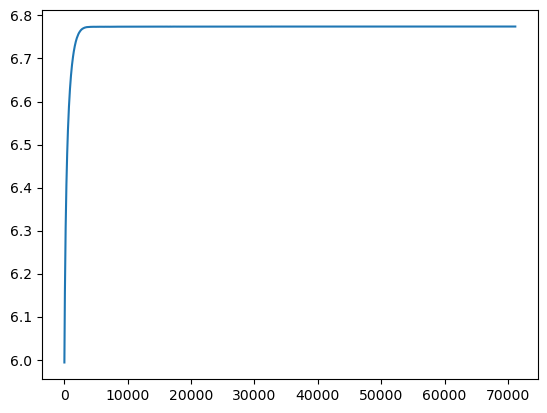

In [103]:
plt.plot(x,np.log(y))

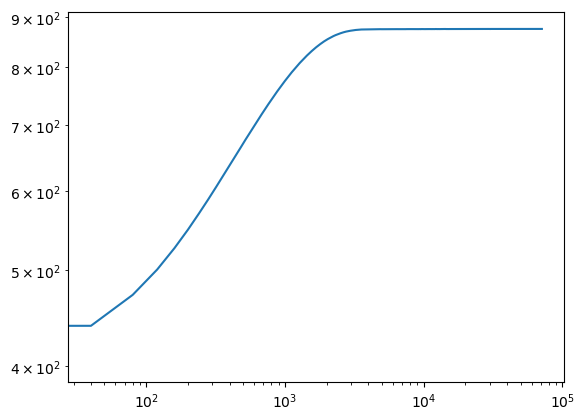

In [ ]:
plt.loglog(x,y)

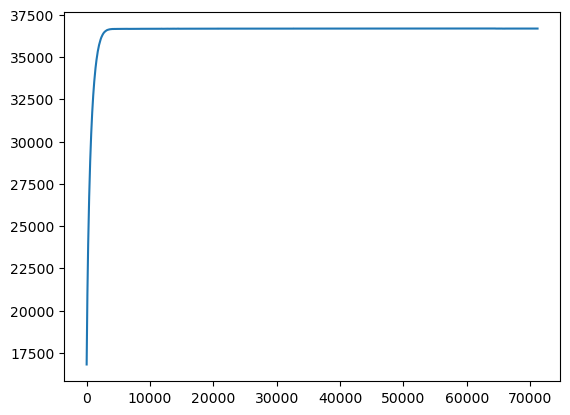

In [110]:
plt.plot(x,sigma_s_series)

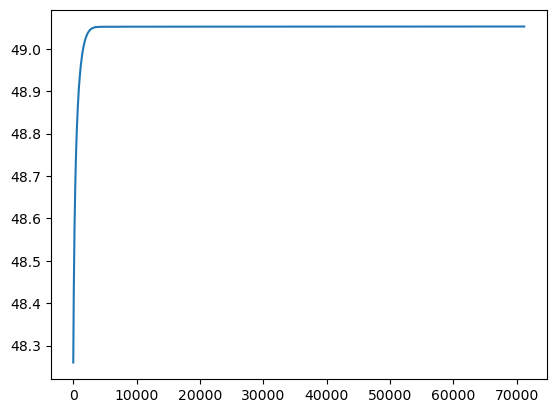

In [96]:
plt.plot(x,np.log(delta_n_series))